# Level 2 — Vision Transformers (ViT-S/16, 선택적으로 Swin-Tiny)

**목표**: ViT (와 선택적으로 Swin-T) 를 직접 구현하고 Multi-task 로 연결하여 Level 1 의 CNN 들과 비교합니다.

**Pretrained 가중치**: ImageNet `.pth` 파일을 본인이 구현한 모델의 `state_dict` 에 로드하는 것은 허용됩니다. 출처를 명시하세요. **`timm` / `torchvision.models` import 는 금지** 입니다.

In [9]:
import os
import sys

# # 1. 코랩 환경에서 레포지토리가 클론되지 않은 경우에만 Clone 진행
# repo_name = "2026-HYU-AUE8088-PA2"
# if not os.path.exists(f"/content/{repo_name}"):
#     !git clone https://github.com/IRCVLab/2026-HYU-AUE8088-PA2.git

# # 2. 작업 디렉토리를 레포지토리의 최상단(Root)으로 변경
# %cd /content/{repo_name}

# 프로젝트 루트를 sys.path에 추가 (src 모듈 인식용)
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2

# 의존성 설치 (이미 설치된 패키지는 빠르게 skip)
!pip install -q -r ../requirements.txt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import torch
from torch import nn
from torch.utils.data import DataLoader

from src.utils.seed import set_seed, seed_worker
from src.utils.transforms import train_transform, eval_transform
from src.utils.trainer import MultiTaskTrainer, TrainConfig
from src.utils.wandb_logger import WandbLogger
from src.utils.metrics import collect_predictions, confusion_matrices, CLASS_NAMES
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES
from src.models.vit import vit_small_patch16_224
# from src.models.swin import SwinTiny  # 선택 사항

SEED = 42
set_seed(SEED, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB / {torch.cuda.mem_get_info()[1]/1e9:.1f} GB")

GPU memory free: 7.6 GB / 10.3 GB


In [13]:
import wandb; wandb.login()   # API key 입력

# wandb 설정 — 비활성화하려면 None
WANDB_PROJECT = "aue8088-pa2"
WANDB_TAGS    = ["level2"]

In [14]:
DATA_ROOT = "../data/set_a"
BATCH = 64

# --- 데이터셋 자동 다운로드 (Google Drive) ---------------------------------
# ../data/set_a 가 없으면 zip 을 받아 상위 폴더에 압축 해제 → ../data/set_a, ../data/set_b 생성.
import os, sys, zipfile, subprocess

GDRIVE_FILE_ID = "1L7YC70QlO87aIbE5lbtQ94HUINJijBKK"
ZIP_PATH   = "../aue8088_pa2_data.zip"
EXTRACT_TO = ".."   # zip 내부 최상위가 data/ 이므로 상위 폴더에 풀면 ../data/... 가 됨

if not os.path.isdir(DATA_ROOT):
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown

    if not os.path.exists(ZIP_PATH):
        print("데이터셋 zip 다운로드 중...")
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print("압축 해제 중...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_TO)
    print(f"완료 → {DATA_ROOT}")
else:
    print(f"데이터셋이 이미 존재합니다 → {DATA_ROOT}")
# --------------------------------------------------------------------------

train_ds = BDDAttrDataset(DATA_ROOT, "train", transform=train_transform())
val_ds   = BDDAttrDataset(DATA_ROOT, "val",   transform=eval_transform())

g = torch.Generator(); g.manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, worker_init_fn=seed_worker, generator=g, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

데이터셋이 이미 존재합니다 → ../data/set_a


In [15]:
# 선택 사항: 본인 ViT 구현체에 ImageNet pretrained 가중치를 로드하는 절차
#
# 진행 방식:
#   1) 공개된 ViT-S/16 체크포인트 (.pth) 를 다운로드.
#   2) 모델 인스턴스 생성:  model = vit_small_patch16_224()
#   3) 키 매핑 후 로드:
#        pre = torch.load('vit_s16.pth')
#        missing, unexpected = model.load_state_dict(remap(pre), strict=False)
#        # Multi-task head 는 task 종속이므로 random init 유지.
#
# 사용한 체크포인트 출처와 매칭된 키 개수를 리포트에 기재하세요.
USE_PRETRAINED = False
model = vit_small_patch16_224().to(device)

In [20]:
epochs = 25
optim = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=5e-2)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
losses = {a: nn.CrossEntropyLoss() for a in ATTRIBUTES}

logger = WandbLogger(
    project=WANDB_PROJECT,
    run_name=f"level2-vit_s16{'-pretrained' if USE_PRETRAINED else ''}",
    config={
        "backbone": "vit_s16", "pretrained": USE_PRETRAINED,
        "epochs": epochs, "batch": BATCH, "lr": 5e-4, "weight_decay": 5e-2, "seed": SEED,
    },
    tags=WANDB_TAGS + ["vit_s16"],
)
trainer = MultiTaskTrainer(model, optim, sched, losses, device, TrainConfig(epochs=epochs), logger=logger)

history = trainer.fit(train_loader, val_loader)

val_pred, _, val_tgt, _ = collect_predictions(model, val_loader, device)
cms = confusion_matrices(val_pred, val_tgt)
for a in ATTRIBUTES:
    logger.log_confusion_matrix(f"final/cm_{a}", cms[a], CLASS_NAMES[a])
logger.finish()

ckpt_name = "level2_vit_s16" + ("_pretrained" if USE_PRETRAINED else "")
os.makedirs("../checkpoints", exist_ok=True)
torch.save({"state_dict": model.state_dict(), "history": history},
           f"../checkpoints/{ckpt_name}.pth")

[epoch 01/25] train_loss=1.8607  val_avg_MF1=0.4657  per={'weather': 0.3212952194315927, 'scene': 0.34306587273513345, 'timeofday': 0.7328148233319333}


[epoch 02/25] train_loss=1.8224  val_avg_MF1=0.4512  per={'weather': 0.3198412698412698, 'scene': 0.29882067576540833, 'timeofday': 0.7348028994816528}


[epoch 03/25] train_loss=1.8048  val_avg_MF1=0.4878  per={'weather': 0.3252981618674015, 'scene': 0.339573637071072, 'timeofday': 0.7983921108866978}


[epoch 04/25] train_loss=1.7976  val_avg_MF1=0.4753  per={'weather': 0.25946894508245766, 'scene': 0.37889771919622667, 'timeofday': 0.7876521289492849}


[epoch 05/25] train_loss=1.7966  val_avg_MF1=0.5061  per={'weather': 0.32731118419203414, 'scene': 0.39545239189367304, 'timeofday': 0.7956607431686965}


...

[epoch 23/25] train_loss=1.5162  val_avg_MF1=0.5484  per={'weather': 0.36603420909705014, 'scene': 0.4537153799448881, 'timeofday': 0.8253172015836254}


[epoch 24/25] train_loss=1.5113  val_avg_MF1=0.5427  per={'weather': 0.3685338378008636, 'scene': 0.4445618190936543, 'timeofday': 0.8149937927854433}


[epoch 25/25] train_loss=1.5057  val_avg_MF1=0.5418  per={'weather': 0.36541217305268286, 'scene': 0.44492250535135525, 'timeofday': 0.8149937927854433}


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,████▇▇▇▆▆▆▅▅▄▄▃▃▃▂▂▂▁▁▁▁▁
train/loss,█▇▇▇▇▇▆▆▆▆▅▅▄▄▄▃▃▃▃▂▂▁▁▁▁
val/avg_macro_f1,▂▁▄▃▅▅▅▂▄▅▆▅▆▅▅▆▇▇▇▇█████
val/mf1_scene,▃▁▃▅▅▃▆▂▆▅▄▄▅▇▅▆▆▇▇▇▇██▇█
val/mf1_timeofday,▁▁▆▅▆▄▃▄▄▇▇▆▆▃▅▆▅▇▇▇███▇▇
val/mf1_weather,▄▄▄▁▅▇▅▄▄▄▇▇▆▆▆▆█▆▆▆▆▆▇▇▇
epoch,25
lr,0
train/loss,1.50572
val/avg_macro_f1,0.54178


## 분석 (리포트 필수 포함 항목)

1. **CNN vs Transformer**: 동일 epoch 예산 하에서 ResNet-50 (Level 1) 과 ViT-S (Level 2) 의 Avg-MF1 을 비교하세요.
2. **Pretrained vs Scratch**: 약 5천 장 규모의 소규모 데이터셋에서 ImageNet 초기화가 실제로 얼마나 도움이 되는지 정량적으로 보고하세요.
3. **속성별 거동**: ViT 가 ResNet 대비 Weather 와 Time of Day 사이의 오류 분포를 다르게 가져가는지, 그 원인을 가설로 제시하세요.

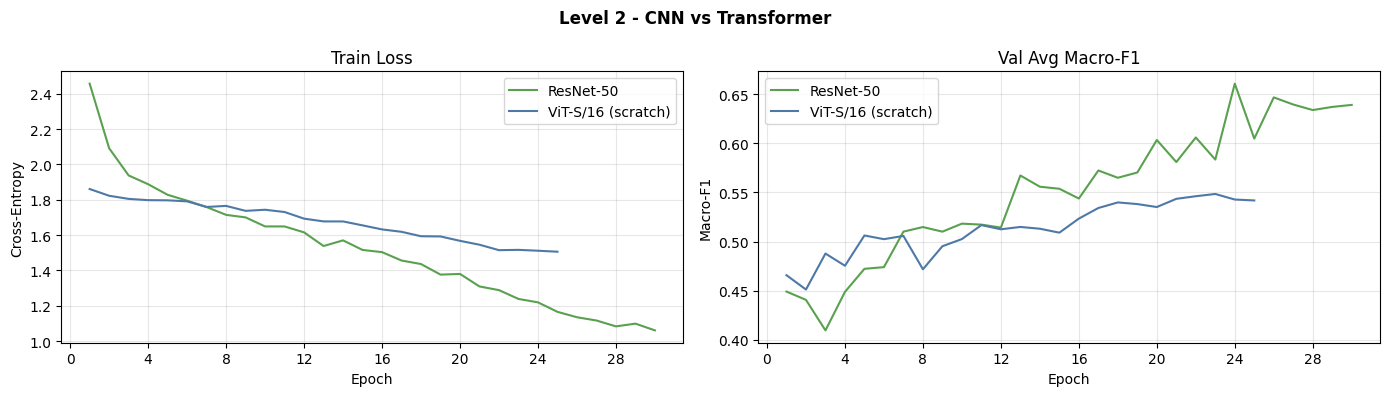

,Avg-MF1,Weather,Scene,TimeOfDay,Best Epoch
Model,,,,,
ResNet-50 (Level 1),0.6606,0.5501,0.6136,0.8180,24
ViT-S/16 scratch,0.5484,0.3660,0.4537,0.8253,23


Pretrained checkpoint not found — showing scratch only


: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

def _load_hist(path):
    if not os.path.exists(path):
        return None
    return torch.load(path, map_location="cpu", weights_only=False).get("history")

r50_hist      = _load_hist("../checkpoints/level1_resnet50.pth")
vit_hist      = locals().get("history") or _load_hist("../checkpoints/level2_vit_s16.pth")
vit_pt_hist   = _load_hist("../checkpoints/level2_vit_s16_pretrained.pth")

COLORS = {"ResNet-50": "#59a14f", "ViT-S/16 (scratch)": "#4e79a7", "ViT-S/16 (pretrained)": "#f28e2b"}

# 1. Convergence: CNN vs Transformer
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, hist in [("ResNet-50", r50_hist), ("ViT-S/16 (scratch)", vit_hist)]:
    if hist is None: continue
    ep = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(ep, hist["train_loss"],  color=COLORS[label], label=label)
    axes[1].plot(ep, hist["val_avg_mf1"], color=COLORS[label], label=label)
for ax, title, ylabel in zip(axes, ["Train Loss", "Val Avg Macro-F1"], ["Cross-Entropy", "Macro-F1"]):
    ax.set(title=title, xlabel="Epoch", ylabel=ylabel)
    ax.legend(); ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.suptitle("Level 2 - CNN vs Transformer", fontweight="bold")
plt.tight_layout()
plt.savefig("../checkpoints/level2_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Per-attribute MF1 table
rows = []
for label, hist in [("ResNet-50 (Level 1)", r50_hist),
                    ("ViT-S/16 scratch",    vit_hist),
                    ("ViT-S/16 pretrained", vit_pt_hist)]:
    if hist is None: continue
    best = int(np.argmax(hist["val_avg_mf1"]))
    per  = hist["val_per_mf1"][best]
    rows.append({"Model": label, "Avg-MF1": round(hist["val_avg_mf1"][best], 4),
                 "Weather": round(per["weather"], 4), "Scene": round(per["scene"], 4),
                 "TimeOfDay": round(per["timeofday"], 4), "Best Epoch": best + 1})
df = pd.DataFrame(rows).set_index("Model")
display(df)

# 3. Pretrained vs Scratch bar chart (if both exist)
scratch = df[df.index.str.contains("scratch")]
pt      = df[df.index.str.contains("pretrained")]
if not scratch.empty and not pt.empty:
    attrs = ["Weather", "Scene", "TimeOfDay", "Avg-MF1"]
    x = np.arange(len(attrs)); w = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(x - w/2, scratch[attrs].values[0], w, label="Scratch",    color="#4e79a7")
    ax.bar(x + w/2, pt[attrs].values[0],      w, label="Pretrained", color="#f28e2b")
    ax.set(xticks=x, xticklabels=attrs, ylabel="Macro-F1",
           title="ViT-S/16: Pretrained vs Scratch")
    ax.legend(); ax.grid(axis="y", alpha=0.3); ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig("../checkpoints/level2_pretrained_vs_scratch.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Pretrained checkpoint not found — showing scratch only")